# Statistical Arbitrage Experiment 2 — Basis-Native Regime Signals

## Goal

This notebook studies a BTC spot–futures basis mean-reversion strategy using **basis-native regime signals**, without relying on the external predicted-volatility overlay as the main driver.

The main questions are:

1. Can basis-native activity signals outperform the plain baseline strategy?
2. Is it better to suppress trading in high-activity regimes, or only trade in those regimes?
3. Which regime signal works best:
   - basis volatility
   - basis realized variation
   - divergence measures
   - basis absolute-move activity
4. How robust are the results to:
   - trading costs
   - entry / exit thresholds
   - lookback windows
   - more realistic execution assumptions

---

## High-level structure

- Build the merged spot / futures basis dataframe
- Add historical volatility and basis-native regime signals
- Run the baseline strategy
- Test hard filters on predicted vol / basis signals
- Run decile analysis
- Test soft scaling and high-vol-only strategies
- Sweep across multiple basis-native signals
- Perform sensitivity analysis
- Add more realistic execution constraints
- Identify the strongest practical version

In [1]:
import os
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def _date_range_yyyymmdd(start_date: str, end_date: str) -> List[str]:
    dates = pd.date_range(start=pd.Timestamp(start_date), end=pd.Timestamp(end_date), freq="D")
    return [d.strftime("%Y%m%d") for d in dates]


def load_bucket_range(
    buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
    mid_col_prefer: str = "mid_last",
    px_fallback_col: str = "px_last",
    prefix: str = "spot",
) -> pd.DataFrame:
    """
    Load bucket parquet files over a date range and return a standardized dataframe.
    """
    dates = _date_range_yyyymmdd(start_date, end_date)

    frames = []
    for d in dates:
        path = os.path.join(buckets_root, f"freq={freq_min}min", f"date={d}", "buckets.parquet")
        if not os.path.exists(path):
            continue
        df = pd.read_parquet(path)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No bucket parquet files found under {buckets_root} for [{start_date}, {end_date}]")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    px = df[mid_col_prefer].copy() if mid_col_prefer in df.columns else pd.Series(np.nan, index=df.index)
    if px_fallback_col in df.columns:
        px = px.fillna(df[px_fallback_col])
    px = px.ffill()

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df["timestamp"], utc=True),
        f"{prefix}_mid": px.astype(float),
    })

    extra_cols = [
        "mid_last",
        "px_last",
        "vol_notional",
        "n_trades",
        "buy_ratio",
        "rel_spread_mean",
        "imbalance_mean",
    ]
    for c in extra_cols:
        if c in df.columns:
            out[f"{prefix}_{c}"] = df[c].values

    return out

In [3]:
def prepare_basis_dataframe(
    spot_buckets_root: str,
    fut_buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Load spot and futures buckets, align on timestamp, and construct basis dataframe.
    """
    spot = load_bucket_range(
        buckets_root=spot_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="spot",
    )
    fut = load_bucket_range(
        buckets_root=fut_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="fut",
    )

    df = (
        spot.merge(fut, on="timestamp", how="inner")
            .sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
    )

    df["log_spot"] = np.log(df["spot_mid"].replace(0, np.nan))
    df["log_fut"] = np.log(df["fut_mid"].replace(0, np.nan))

    df["ret_spot"] = df["log_spot"].diff()
    df["ret_fut"] = df["log_fut"].diff()

    df["basis"] = df["log_fut"] - df["log_spot"]
    df["basis_ret"] = df["basis"].diff()

    return df

In [4]:
def add_historical_vol_signal(
    df: pd.DataFrame,
    hist_horizon_min: int = 30,
    freq_min: int = 1,
    out_col: str = "hist_vol_spot_30m",
) -> pd.DataFrame:
    out = df.copy()
    W = int(round(hist_horizon_min / freq_min))
    out["ret_spot2"] = out["ret_spot"] ** 2
    out[out_col] = out["ret_spot2"].rolling(W, min_periods=W).sum()
    return out


def add_basis_specific_signals(
    df: pd.DataFrame,
    freq_min: int = 1,
    basis_vol_horizon_min: int = 30,
    div_horizon_min: int = 30,
) -> pd.DataFrame:
    out = df.copy()

    Wb = int(round(basis_vol_horizon_min / freq_min))
    Wd = int(round(div_horizon_min / freq_min))

    out["basis_vol_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()
    out["basis_rv_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()

    out["div_30m_mean"] = out["basis"].abs().rolling(Wd, min_periods=Wd).mean()
    out["div_30m_max"] = out["basis"].abs().rolling(Wd, min_periods=Wd).max()

    return out

In [5]:
def merge_predicted_vol_signal(
    df: pd.DataFrame,
    pred_df: pd.DataFrame,
    pred_col: str,
    timestamp_col: str = "timestamp",
    out_col: str = "pred_vol_spot_30m",
) -> pd.DataFrame:
    pred = pred_df.copy()
    pred[timestamp_col] = pd.to_datetime(pred[timestamp_col], utc=True)
    pred = pred[[timestamp_col, pred_col]].rename(columns={timestamp_col: "timestamp", pred_col: out_col})
    pred = (
        pred.sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
    )

    out = df.merge(pred, on="timestamp", how="left")
    return out

In [6]:
def run_basis_zscore_strategy(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_col: Optional[str] = None,
    vol_filter_quantile: float = 0.90,
    vol_filter_lookback_min: int = 30 * 24 * 60,
    high_vol_only: bool = False,
) -> pd.DataFrame:
    """
    If vol_filter_col is not None:
      - high_vol_only=False: allow entry only when vol <= rolling quantile threshold
      - high_vol_only=True : allow entry only when vol >= rolling quantile threshold
    """
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if vol_filter_col is not None:
        VW = int(round(vol_filter_lookback_min / freq_min))
        out["vol_filter_threshold"] = (
            out[vol_filter_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(vol_filter_quantile)
            .shift(1)
        )
    else:
        out["vol_filter_threshold"] = np.nan

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0:
            allow_entry = True

            if vol_filter_col is not None:
                thr = out.at[i, "vol_filter_threshold"]
                sig = out.at[i, vol_filter_col]

                if pd.isna(thr) or pd.isna(sig):
                    allow_entry = False
                else:
                    if high_vol_only:
                        allow_entry = bool(sig >= thr)
                    else:
                        allow_entry = bool(sig <= thr)

            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                elif z < -entry_z:
                    prev_pos = 1

        pos[i] = prev_pos

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)

    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [7]:
def build_size_multiplier_from_quantiles(
    signal: pd.Series,
    freq_min: int = 1,
    lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 1.0,
    size_mid: float = 0.7,
    size_high: float = 0.4,
    size_extreme: float = 0.15,
) -> pd.Series:
    W = int(round(lookback_min / freq_min))

    q1s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q1).shift(1)
    q2s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q2).shift(1)
    q3s = signal.rolling(W, min_periods=max(100, int(0.5 * W))).quantile(q3).shift(1)

    mult = pd.Series(np.nan, index=signal.index, dtype=float)
    ready = q1s.notna() & q2s.notna() & q3s.notna()

    mult.loc[ready] = size_low
    mult.loc[ready & (signal > q1s)] = size_mid
    mult.loc[ready & (signal > q2s)] = size_high
    mult.loc[ready & (signal > q3s)] = size_extreme

    return mult


def run_basis_zscore_strategy_with_scaling(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    scale_col: Optional[str] = None,
    scale_lookback_min: int = 30 * 24 * 60,
    q1: float = 0.80,
    q2: float = 0.90,
    q3: float = 0.97,
    size_low: float = 1.0,
    size_mid: float = 0.7,
    size_high: float = 0.4,
    size_extreme: float = 0.15,
) -> pd.DataFrame:
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    pos = np.zeros(len(out), dtype=float)

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            continue

        if prev_pos == 1 and abs(z) < exit_z:
            prev_pos = 0
        elif prev_pos == -1 and abs(z) < exit_z:
            prev_pos = 0

        if prev_pos == 0:
            if z > entry_z:
                prev_pos = -1
            elif z < -entry_z:
                prev_pos = 1

        pos[i] = prev_pos

    out["raw_position"] = pos

    if scale_col is not None:
        mult = build_size_multiplier_from_quantiles(
            out[scale_col],
            freq_min=freq_min,
            lookback_min=scale_lookback_min,
            q1=q1, q2=q2, q3=q3,
            size_low=size_low,
            size_mid=size_mid,
            size_high=size_high,
            size_extreme=size_extreme,
        )
        out["size_multiplier"] = mult.fillna(0.0)
    else:
        out["size_multiplier"] = 1.0

    out["position"] = out["raw_position"] * out["size_multiplier"]
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)

    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out

In [8]:
def max_drawdown(cum_curve: pd.Series) -> float:
    peak = cum_curve.cummax()
    dd = cum_curve - peak
    return float(dd.min())


def summarize_backtest(bt: pd.DataFrame, freq_min: int = 1) -> pd.Series:
    r = bt["net_pnl"].fillna(0.0)
    g = bt["gross_pnl"].fillna(0.0)

    periods_per_year = 365 * 24 * (60 // freq_min)
    mean_r = r.mean()
    std_r = r.std()

    ann_return = mean_r * periods_per_year
    ann_vol = std_r * np.sqrt(periods_per_year) if std_r > 0 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

    cum_net = r.cumsum()
    cum_gross = g.cumsum()

    out = pd.Series({
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "cum_net_pnl": cum_net.iloc[-1] if len(cum_net) else np.nan,
        "cum_gross_pnl": cum_gross.iloc[-1] if len(cum_gross) else np.nan,
        "max_drawdown": max_drawdown(cum_net) if len(cum_net) else np.nan,
        "n_bars": len(bt),
        "n_trade_opens": int(((bt["position"] != 0) & (bt["position"].shift(1).fillna(0) == 0)).sum()),
    })
    return out


def plot_cum_pnl(bt_dict: Dict[str, pd.DataFrame], pnl_col: str = "net_pnl", title: str = "Cumulative PnL"):
    plt.figure(figsize=(12, 6))
    for name, bt in bt_dict.items():
        curve = bt[pnl_col].fillna(0).cumsum()
        plt.plot(bt["timestamp"], curve, label=name)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("cum pnl")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
def add_next_bar_baseline_pnl(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_values("timestamp").reset_index(drop=True)
    out["next_basis_ret"] = out["basis_ret"].shift(-1)
    return out


def decile_analysis_for_signal(
    df: pd.DataFrame,
    signal_col: str,
    basis_z_col: str = "basis_z",
    next_ret_col: str = "next_basis_ret",
    entry_z: float = 2.0,
    n_bins: int = 10,
) -> pd.DataFrame:
    x = df[[signal_col, basis_z_col, next_ret_col]].dropna().copy()
    x["decile"] = pd.qcut(x[signal_col], q=n_bins, labels=False, duplicates="drop") + 1

    x["mr_trade_flag"] = 0
    x.loc[x[basis_z_col] > entry_z, "mr_trade_flag"] = -1
    x.loc[x[basis_z_col] < -entry_z, "mr_trade_flag"] = 1
    x["mr_next_bar_pnl"] = x["mr_trade_flag"] * x[next_ret_col]

    out = x.groupby("decile").agg(
        n=(signal_col, "size"),
        signal_mean=(signal_col, "mean"),
        next_basis_ret_mean=(next_ret_col, "mean"),
        next_basis_ret_std=(next_ret_col, "std"),
        mr_trade_count=("mr_trade_flag", lambda s: (s != 0).sum()),
        mr_next_bar_pnl_mean=("mr_next_bar_pnl", "mean"),
        mr_next_bar_pnl_std=("mr_next_bar_pnl", "std"),
    ).reset_index()

    return out

## Load data and build the market dataframe

This notebook uses:

- spot buckets from `/Volumes/profit/feature_store/buckets`
- futures buckets from `/Volumes/profit/feature_store_futures/buckets`
- 30m OOS spot-vol predictions from the first notebook

We then construct:

- historical spot volatility
- basis-native regime signals
- merged predicted volatility signal

In [10]:
# ========= CONFIG =========
spot_buckets_root = "/Volumes/profit/feature_store/buckets"
fut_buckets_root = "/Volumes/profit/feature_store_futures/buckets"
spot_pred_path = "/Volumes/profit/stat_arb_test/spot_vol_oos_pred_30m.parquet"

freq_min = 1
start_date = "2025-11-01"
end_date = "2026-03-10"

entry_z = 2.0
exit_z = 0.5
basis_lookback_min = 240
cost_bps = 2.0

# ========= LOAD =========
df_mkt = prepare_basis_dataframe(
    spot_buckets_root=spot_buckets_root,
    fut_buckets_root=fut_buckets_root,
    freq_min=freq_min,
    start_date=start_date,
    end_date=end_date,
)

df_mkt = add_historical_vol_signal(
    df_mkt,
    hist_horizon_min=30,
    freq_min=freq_min,
    out_col="hist_vol_spot_30m",
)

df_mkt = add_basis_specific_signals(
    df_mkt,
    freq_min=freq_min,
    basis_vol_horizon_min=30,
    div_horizon_min=30,
)

spot_pred = pd.read_parquet(spot_pred_path)
df_all = merge_predicted_vol_signal(
    df_mkt,
    spot_pred,
    pred_col="pred_y_30m",
    timestamp_col="timestamp",
    out_col="pred_vol_spot_30m",
)

print(df_all[[
    "timestamp", "spot_mid", "fut_mid", "basis", "basis_ret",
    "hist_vol_spot_30m", "basis_vol_30m", "basis_rv_30m",
    "div_30m_mean", "div_30m_max", "pred_vol_spot_30m"
]].head())

print(df_all.shape)

                  timestamp    spot_mid    fut_mid     basis  basis_ret  \
0 2025-11-01 00:00:00+00:00  109616.345  109572.35 -0.000401        NaN   
1 2025-11-01 00:01:00+00:00  109550.465  109507.25 -0.000395   0.000007   
2 2025-11-01 00:02:00+00:00  109470.925  109426.55 -0.000405  -0.000011   
3 2025-11-01 00:03:00+00:00  109447.005  109418.85 -0.000257   0.000148   
4 2025-11-01 00:04:00+00:00  109444.445  109405.05 -0.000360  -0.000103   

   hist_vol_spot_30m  basis_vol_30m  basis_rv_30m  div_30m_mean  div_30m_max  \
0                NaN            NaN           NaN           NaN          NaN   
1                NaN            NaN           NaN           NaN          NaN   
2                NaN            NaN           NaN           NaN          NaN   
3                NaN            NaN           NaN           NaN          NaN   
4                NaN            NaN           NaN           NaN          NaN   

   pred_vol_spot_30m  
0                NaN  
1                NaN  

## Baseline strategy

We first run the plain basis z-score mean-reversion strategy with no regime filter.

This is the benchmark that every modified version must beat.

In [11]:
bt_no = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col=None,
)

summary_no = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min)
}).T

print(summary_no)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  


## Hard filters using predicted volatility

We first test the naive idea:

- avoid trading when predicted volatility is high

We check q90 and q99 filters.

In [12]:
bt_spot_pred_q90 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="pred_vol_spot_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_spot_pred_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="pred_vol_spot_30m",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_spot_pred = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "spot_pred_q90": summarize_backtest(bt_spot_pred_q90, freq_min=freq_min),
    "spot_pred_q99": summarize_backtest(bt_spot_pred_q99, freq_min=freq_min),
}).T

print(summary_spot_pred)

               ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter        2.031278  0.238525  8.515994     0.713227       2.900027   
spot_pred_q90   -0.703292  0.103348 -6.805115    -0.246942       0.998258   
spot_pred_q99    0.588515  0.160247  3.672556     0.206641       1.648641   

               max_drawdown    n_bars  n_trade_opens  
no_filter         -0.199412  184550.0         5467.0  
spot_pred_q90     -0.358406  184550.0         3113.0  
spot_pred_q99     -0.219520  184550.0         3605.0  


## Hard filters using basis-native regime signals

We now test suppression filters based on:

- `basis_vol_30m`
- `div_30m_mean`

These are not external model outputs.  
They are constructed directly from basis dynamics.

In [14]:
bt_basis_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_basis_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_basis_filter = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_q95": summarize_backtest(bt_basis_q95, freq_min=freq_min),
    "basis_q99": summarize_backtest(bt_basis_q99, freq_min=freq_min),
}).T

print(summary_basis_filter)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   
basis_q95   -0.499239  0.143214 -3.485957    -0.175294       1.548706   
basis_q99    1.073318  0.202396  5.303062     0.376866       2.244066   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  
basis_q95     -0.355952  184550.0         4310.0  
basis_q99     -0.218766  184550.0         4668.0  


In [15]:
bt_div_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="div_30m_mean",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
)

bt_div_q99 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="div_30m_mean",
    vol_filter_quantile=0.99,
    vol_filter_lookback_min=30 * 24 * 60,
)

summary_div_filter = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "div_q95": summarize_backtest(bt_div_q95, freq_min=freq_min),
    "div_q99": summarize_backtest(bt_div_q99, freq_min=freq_min),
}).T

print(summary_div_filter)

           ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter    2.031278  0.238525  8.515994     0.713227       2.900027   
div_q95     -0.302124  0.151229 -1.997789    -0.106083       1.624717   
div_q99      1.013053  0.200810  5.044839     0.355706       2.217306   

           max_drawdown    n_bars  n_trade_opens  
no_filter     -0.199412  184550.0         5467.0  
div_q95       -0.323861  184550.0         4327.0  
div_q99       -0.215681  184550.0         4654.0  


## Decile analysis

Before fully committing to any filter, we look at whether stronger regime signals correspond to stronger next-bar mean-reversion opportunity.

This is the key diagnostic step that motivates the later high-vol-only strategies.

In [17]:
tmp = bt_no.copy()
tmp = add_next_bar_baseline_pnl(tmp)

dec_basis_vol = decile_analysis_for_signal(
    tmp,
    signal_col="basis_vol_30m",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=entry_z,
    n_bins=10,
)

dec_div = decile_analysis_for_signal(
    tmp,
    signal_col="div_30m_mean",
    basis_z_col="basis_z",
    next_ret_col="next_basis_ret",
    entry_z=entry_z,
    n_bins=10,
)

print("Basis vol deciles")
print(dec_basis_vol)

print("\nDivergence deciles")
print(dec_div)

Basis vol deciles
   decile      n   signal_mean  next_basis_ret_mean  next_basis_ret_std  \
0       1  18431  7.351484e-08        -5.799942e-07            0.000090   
1       2  18431  1.139325e-07        -7.966457e-07            0.000083   
2       3  18431  1.440890e-07         2.333245e-07            0.000098   
3       4  18431  1.755904e-07        -7.843777e-07            0.000103   
4       5  18431  2.144589e-07        -6.922427e-07            0.000109   
5       6  18431  2.699060e-07         1.247863e-06            0.000127   
6       7  18431  3.711564e-07        -5.026600e-07            0.000140   
7       8  18431  6.267168e-07         3.204561e-07            0.000206   
8       9  18431  1.941946e-06         1.885765e-06            0.000352   
9      10  18431  4.759708e-05        -3.362956e-07            0.001212   

   mr_trade_count  mr_next_bar_pnl_mean  mr_next_bar_pnl_std  
0             601              0.000002             0.000019  
1             678             

## Soft scaling based on basis volatility

The next idea is to keep trading, but reduce position size when basis activity is high.

In [18]:
bt_basis_scale = run_basis_zscore_strategy_with_scaling(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    scale_col="basis_vol_30m",
    scale_lookback_min=30 * 24 * 60,
    q1=0.80,
    q2=0.90,
    q3=0.97,
    size_low=1.0,
    size_mid=0.7,
    size_high=0.4,
    size_extreme=0.15,
)

summary_basis_scale = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_scale": summarize_backtest(bt_basis_scale, freq_min=freq_min),
}).T

print(summary_basis_scale)

             ann_return   ann_vol    sharpe  cum_net_pnl  cum_gross_pnl  \
no_filter      2.031278  0.238525  8.515994     0.713227       2.900027   
basis_scale   -0.522428  0.082099 -6.363374    -0.183436       1.443644   

             max_drawdown    n_bars  n_trade_opens  
no_filter       -0.199412  184550.0         5467.0  
basis_scale     -0.369537  184550.0         4761.0  


## High-vol-only basis-vol strategy

Now we test the opposite framing:

- only allow entry when basis volatility is high

In [20]:
bt_basis_high_only_q95 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.95,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q90 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.90,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q85 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.85,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q80 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_basis_high_only_q75 = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=basis_lookback_min,
    freq_min=freq_min,
    entry_z=entry_z,
    exit_z=exit_z,
    cost_bps=cost_bps,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.75,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

summary_basis_high_only = pd.DataFrame({
    "no_filter": summarize_backtest(bt_no, freq_min=freq_min),
    "basis_high_only_q95": summarize_backtest(bt_basis_high_only_q95, freq_min=freq_min),
    "basis_high_only_q90": summarize_backtest(bt_basis_high_only_q90, freq_min=freq_min),
    "basis_high_only_q85": summarize_backtest(bt_basis_high_only_q85, freq_min=freq_min),
    "basis_high_only_q80": summarize_backtest(bt_basis_high_only_q80, freq_min=freq_min),
    "basis_high_only_q75": summarize_backtest(bt_basis_high_only_q75, freq_min=freq_min),
}).T

summary_basis_high_only

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens
no_filter,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0
basis_high_only_q95,3.081831,0.201733,15.276787,1.082100,1.306100,-0.024118,184550.0,560.0
basis_high_only_q90,3.637622,0.220405,16.504293,1.277251,1.634451,-0.023460,184550.0,893.0
basis_high_only_q85,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0
basis_high_only_q80,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0
basis_high_only_q75,3.889195,0.227902,17.065180,1.365584,2.044784,-0.023602,184550.0,1698.0


## Add more direct basis activity signals

We now enrich the basis-native regime set with simple absolute-move activity measures.

In [22]:
df_all = df_all.copy()

df_all["basis_absret"] = df_all["basis_ret"].abs()
df_all["basis_absret_30m_mean"] = df_all["basis_absret"].rolling(30, min_periods=30).mean()
df_all["basis_absret_30m_max"] = df_all["basis_absret"].rolling(30, min_periods=30).max()

print(df_all[[
    "basis_vol_30m",
    "basis_rv_30m",
    "div_30m_mean",
    "div_30m_max",
    "basis_absret_30m_mean",
    "basis_absret_30m_max",
]].tail())

        basis_vol_30m  basis_rv_30m  div_30m_mean  div_30m_max  \
184545   4.134042e-07  4.134042e-07      0.000483      0.00061   
184546   4.141282e-07  4.141282e-07      0.000482      0.00061   
184547   4.077899e-07  4.077899e-07      0.000477      0.00061   
184548   3.971607e-07  3.971607e-07      0.000475      0.00061   
184549   3.972224e-07  3.972224e-07      0.000472      0.00061   

        basis_absret_30m_mean  basis_absret_30m_max  
184545               0.000080              0.000351  
184546               0.000080              0.000351  
184547               0.000078              0.000351  
184548               0.000076              0.000351  
184549               0.000076              0.000351  


In [23]:
def run_high_only_for_signal(
    df: pd.DataFrame,
    signal_col: str,
    q: float,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_lookback_min: int = 30 * 24 * 60,
):
    bt = run_basis_zscore_strategy(
        df=df,
        basis_lookback_min=basis_lookback_min,
        freq_min=freq_min,
        entry_z=entry_z,
        exit_z=exit_z,
        cost_bps=cost_bps,
        vol_filter_col=signal_col,
        vol_filter_quantile=q,
        vol_filter_lookback_min=vol_filter_lookback_min,
        high_vol_only=True,
    )
    sm = summarize_backtest(bt, freq_min=freq_min)
    return bt, sm

In [24]:
qs = [0.80, 0.85, 0.90, 0.95]

results = []
bt_store = {}

for sig in [
    "basis_vol_30m",
    "basis_rv_30m",
    "div_30m_mean",
    "div_30m_max",
    "basis_absret_30m_mean",
    "basis_absret_30m_max",
]:
    for q in qs:
        bt, sm = run_high_only_for_signal(
            df_all,
            signal_col=sig,
            q=q,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=2.0,
            exit_z=0.5,
            cost_bps=2.0,
            vol_filter_lookback_min=30 * 24 * 60,
        )
        name = f"{sig}_high_only_q{int(q*100)}"
        bt_store[name] = bt

        row = sm.to_dict()
        row["signal"] = sig
        row["q"] = q
        row["name"] = name
        results.append(row)

summary_grid = pd.DataFrame(results).sort_values("sharpe", ascending=False)
summary_grid

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,signal,q,name
21,3.974980,0.225653,17.615443,1.395705,1.899305,-0.023460,184550.0,1259.0,basis_absret_30m_max,0.85,basis_absret_30m_max_high_only_q85
20,3.994309,0.227564,17.552492,1.402492,2.021292,-0.023460,184550.0,1547.0,basis_absret_30m_max,0.80,basis_absret_30m_max_high_only_q80
13,3.932798,0.225557,17.435935,1.380894,1.879294,-0.023460,184550.0,1246.0,div_30m_max,0.85,div_30m_max_high_only_q85
0,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_30m,0.80,basis_vol_30m_high_only_q80
4,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_30m,0.80,basis_rv_30m_high_only_q80
1,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0,basis_vol_30m,0.85,basis_vol_30m_high_only_q85
5,3.836108,0.224781,17.065961,1.346944,1.824944,-0.023460,184550.0,1195.0,basis_rv_30m,0.85,basis_rv_30m_high_only_q85
12,3.849529,0.226975,16.960173,1.351656,1.973256,-0.024002,184550.0,1554.0,div_30m_max,0.80,div_30m_max_high_only_q80
14,3.766249,0.222103,16.957242,1.322415,1.696015,-0.023460,184550.0,934.0,div_30m_max,0.90,div_30m_max_high_only_q90
22,3.753262,0.222065,16.901638,1.317855,1.689455,-0.023460,184550.0,929.0,basis_absret_30m_max,0.90,basis_absret_30m_max_high_only_q90


In [25]:
best_by_signal = (
    summary_grid.sort_values("sharpe", ascending=False)
                .groupby("signal", as_index=False)
                .first()
                .sort_values("sharpe", ascending=False)
)

best_by_signal

,signal,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,q,name
0,basis_absret_30m_max,3.974980,0.225653,17.615443,1.395705,1.899305,-0.023460,184550.0,1259.0,0.85,basis_absret_30m_max_high_only_q85
4,div_30m_max,3.932798,0.225557,17.435935,1.380894,1.879294,-0.023460,184550.0,1246.0,0.85,div_30m_max_high_only_q85
2,basis_rv_30m,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,0.80,basis_rv_30m_high_only_q80
3,basis_vol_30m,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,0.80,basis_vol_30m_high_only_q80
1,basis_absret_30m_mean,3.762205,0.225589,16.677271,1.320995,1.873395,-0.023602,184550.0,1381.0,0.80,basis_absret_30m_mean_high_only_q80
5,div_30m_mean,3.424818,0.217249,15.764489,1.202531,1.763731,-0.026729,184550.0,1403.0,0.80,div_30m_mean_high_only_q80


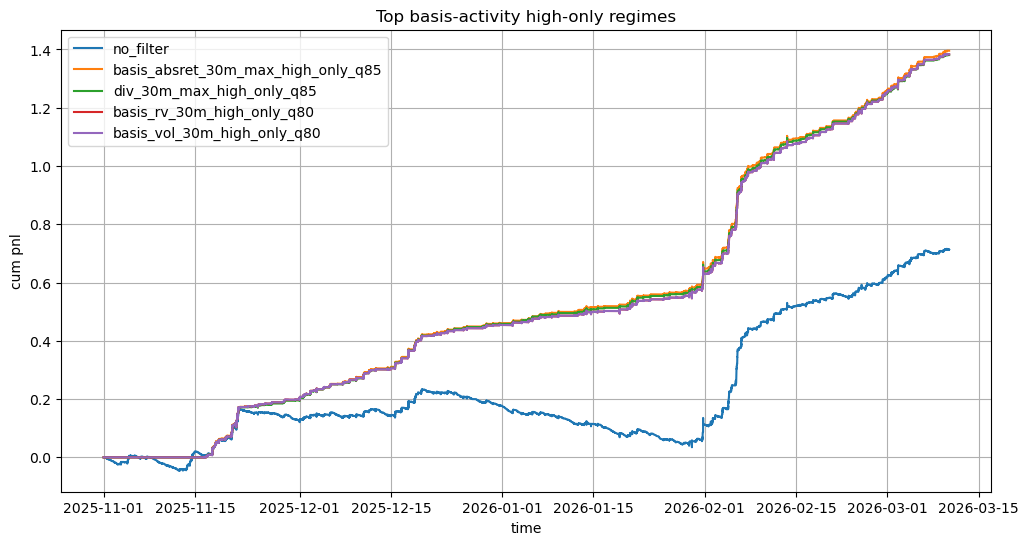

In [26]:
top_names = best_by_signal["name"].head(4).tolist()

plot_dict = {"no_filter": bt_no}
for n in top_names:
    plot_dict[n] = bt_store[n]

plot_cum_pnl(
    plot_dict,
    pnl_col="net_pnl",
    title="Top basis-activity high-only regimes"
)

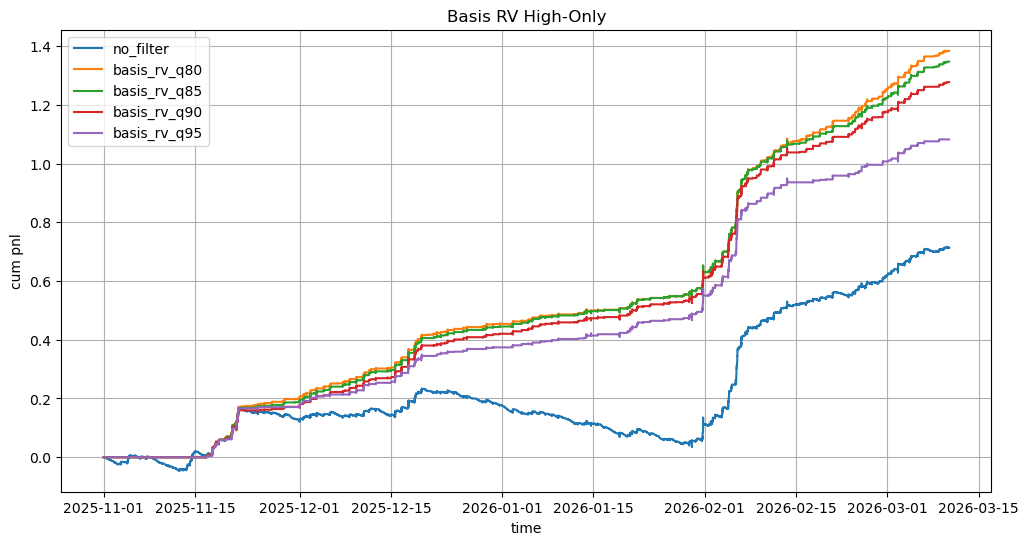

In [27]:
plot_cum_pnl(
    {
        "no_filter": bt_no,
        "basis_rv_q80": bt_store["basis_rv_30m_high_only_q80"],
        "basis_rv_q85": bt_store["basis_rv_30m_high_only_q85"],
        "basis_rv_q90": bt_store["basis_rv_30m_high_only_q90"],
        "basis_rv_q95": bt_store["basis_rv_30m_high_only_q95"],
    },
    pnl_col="net_pnl",
    title="Basis RV High-Only"
)

## Cost sensitivity

We now test whether the apparent advantage survives under higher transaction cost assumptions.

In [28]:
def run_cost_sensitivity(
    df: pd.DataFrame,
    cost_list=(2.0, 5.0, 10.0),
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
):
    rows = []
    bt_store = {}

    for cost in cost_list:
        bt_base = run_basis_zscore_strategy(
            df=df,
            basis_lookback_min=basis_lookback_min,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            cost_bps=cost,
            vol_filter_col=None,
        )
        bt_store[f"no_filter_cost{int(cost)}"] = bt_base
        row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
        row["strategy"] = "no_filter"
        row["cost_bps"] = cost
        rows.append(row)

        for sig, q in [("basis_vol_30m", 0.80), ("basis_rv_30m", 0.80)]:
            bt = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=basis_lookback_min,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost,
                vol_filter_col=sig,
                vol_filter_quantile=q,
                vol_filter_lookback_min=30 * 24 * 60,
                high_vol_only=True,
            )
            key = f"{sig.replace('_30m','')}_q80_cost{int(cost)}"
            bt_store[key] = bt

            row = summarize_backtest(bt, freq_min=freq_min).to_dict()
            row["strategy"] = key.replace(f"_cost{int(cost)}", "")
            row["cost_bps"] = cost
            rows.append(row)

    return pd.DataFrame(rows), bt_store

In [29]:
summary_cost, bt_cost_store = run_cost_sensitivity(
    df_all,
    cost_list=(2.0, 5.0, 10.0),
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
)

summary_cost

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,cost_bps
0,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,no_filter,2.0
1,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_q80,2.0
2,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_q80,2.0
3,-7.310760,0.247423,-29.547665,-2.566973,2.900027,-2.566973,184550.0,5467.0,no_filter,5.0
4,1.460762,0.227621,6.417530,0.512906,1.963906,-0.107137,184550.0,1451.0,basis_vol_q80,5.0
5,1.460762,0.227621,6.417530,0.512906,1.963906,-0.107137,184550.0,1451.0,basis_rv_q80,5.0
6,-22.880824,0.283094,-80.824065,-8.033973,2.900027,-8.033973,184550.0,5467.0,no_filter,10.0
7,-2.671699,0.236368,-11.303125,-0.938094,1.963906,-0.938094,184550.0,1451.0,basis_vol_q80,10.0
8,-2.671699,0.236368,-11.303125,-0.938094,1.963906,-0.938094,184550.0,1451.0,basis_rv_q80,10.0


In [30]:
summary_cost.pivot(index="cost_bps", columns="strategy", values="sharpe")

strategy,basis_rv_q80,basis_vol_q80,no_filter
cost_bps,,,
2.0,17.391786,17.391786,8.515994
5.0,6.417530,6.417530,-29.547665
10.0,-11.303125,-11.303125,-80.824065


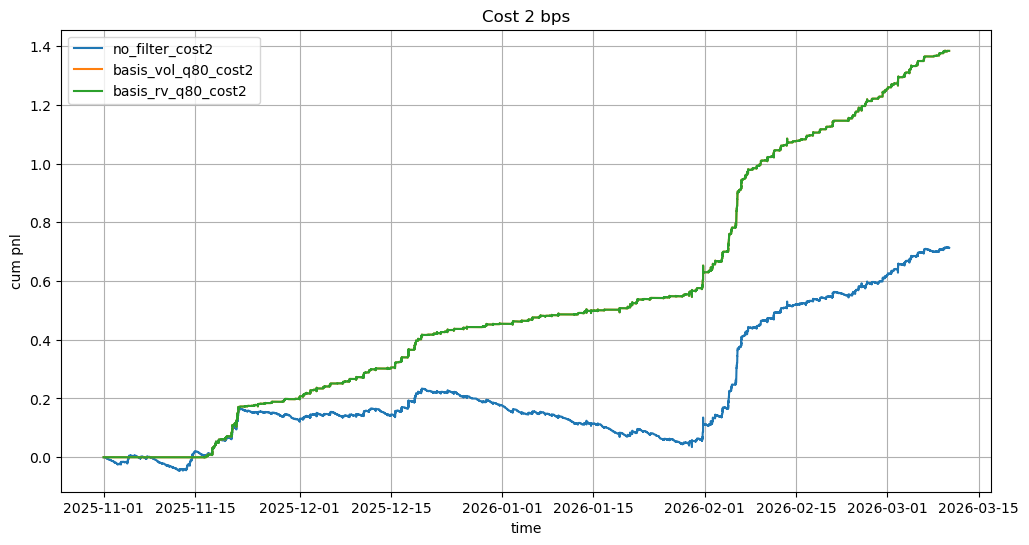

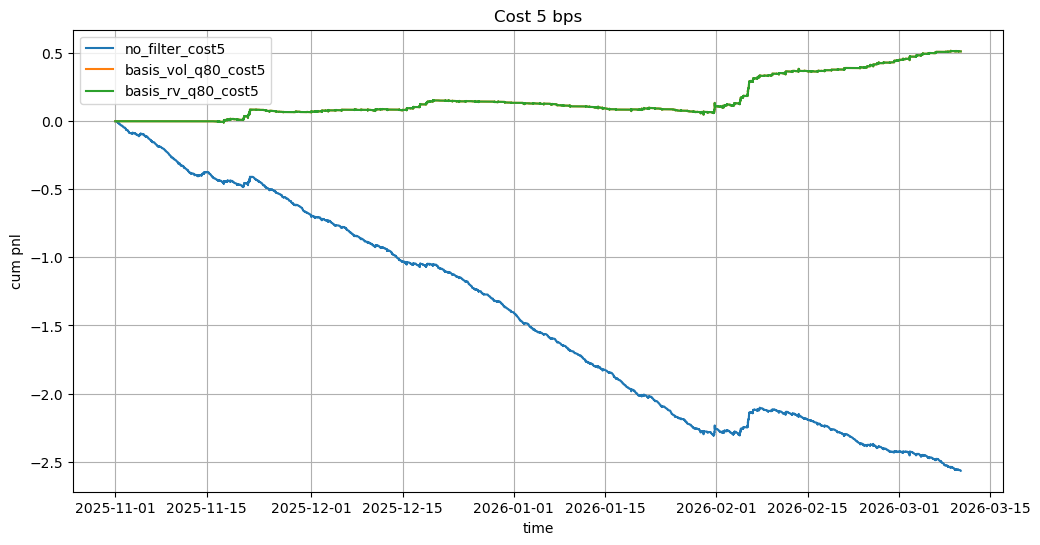

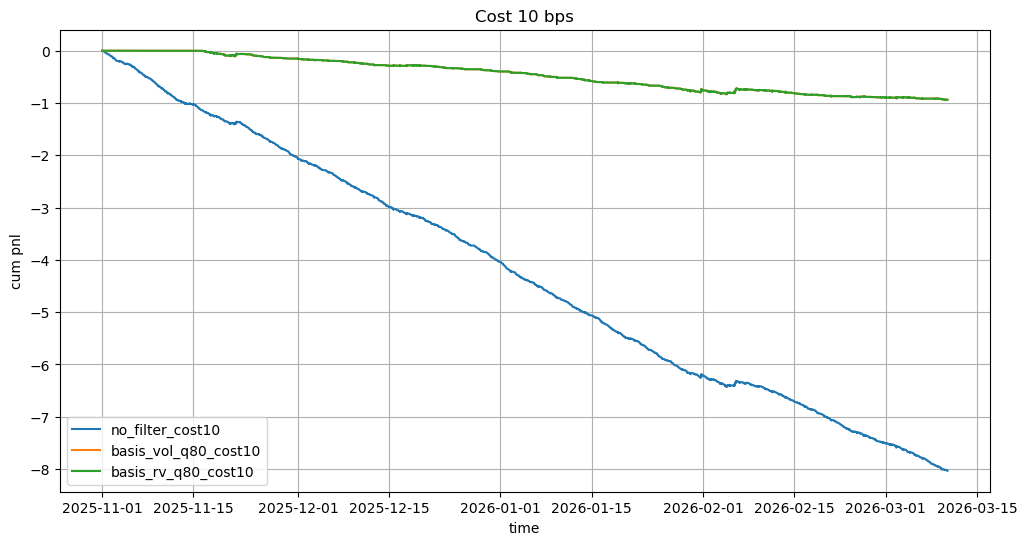

In [31]:
plot_cum_pnl(
    {
        "no_filter_cost2": bt_cost_store["no_filter_cost2"],
        "basis_vol_q80_cost2": bt_cost_store["basis_vol_q80_cost2"],
        "basis_rv_q80_cost2": bt_cost_store["basis_rv_q80_cost2"],
    },
    title="Cost 2 bps"
)

plot_cum_pnl(
    {
        "no_filter_cost5": bt_cost_store["no_filter_cost5"],
        "basis_vol_q80_cost5": bt_cost_store["basis_vol_q80_cost5"],
        "basis_rv_q80_cost5": bt_cost_store["basis_rv_q80_cost5"],
    },
    title="Cost 5 bps"
)

plot_cum_pnl(
    {
        "no_filter_cost10": bt_cost_store["no_filter_cost10"],
        "basis_vol_q80_cost10": bt_cost_store["basis_vol_q80_cost10"],
        "basis_rv_q80_cost10": bt_cost_store["basis_rv_q80_cost10"],
    },
    title="Cost 10 bps"
)

## Entry / exit sensitivity

We now check whether the stronger regimes pair better with more aggressive or more selective thresholds.

In [32]:
def run_entry_exit_sensitivity(
    df: pd.DataFrame,
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.25, 0.5, 1.0),
    cost_bps=2.0,
    basis_lookback_min=240,
    freq_min=1,
):
    rows = []
    bt_store = {}

    for entry_z in entry_list:
        for exit_z in exit_list:
            bt_base = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=basis_lookback_min,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost_bps,
                vol_filter_col=None,
            )
            name_base = f"baseline_e{entry_z}_x{exit_z}"
            bt_store[name_base] = bt_base
            row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
            row.update({"strategy": "baseline", "entry_z": entry_z, "exit_z": exit_z})
            rows.append(row)

            for sig in ["basis_vol_30m", "basis_rv_30m"]:
                bt = run_basis_zscore_strategy(
                    df=df,
                    basis_lookback_min=basis_lookback_min,
                    freq_min=freq_min,
                    entry_z=entry_z,
                    exit_z=exit_z,
                    cost_bps=cost_bps,
                    vol_filter_col=sig,
                    vol_filter_quantile=0.80,
                    vol_filter_lookback_min=30 * 24 * 60,
                    high_vol_only=True,
                )
                name = f"{sig}_q80_e{entry_z}_x{exit_z}"
                bt_store[name] = bt

                row = summarize_backtest(bt, freq_min=freq_min).to_dict()
                row.update({"strategy": sig, "entry_z": entry_z, "exit_z": exit_z})
                rows.append(row)

    return pd.DataFrame(rows), bt_store

In [33]:
summary_ex, bt_ex_store = run_entry_exit_sensitivity(
    df_all,
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.25, 0.5, 1.0),
    cost_bps=2.0,
    basis_lookback_min=240,
    freq_min=1,
)

summary_ex

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,entry_z,exit_z
0,-0.737178,0.258909,-2.847252,-0.258840,3.021560,-0.682443,184550.0,8201.0,baseline,1.5,0.25
1,3.530791,0.243955,14.473100,1.239740,1.917340,-0.025467,184550.0,1694.0,basis_vol_30m,1.5,0.25
2,3.530791,0.243955,14.473100,1.239740,1.917340,-0.025467,184550.0,1694.0,basis_rv_30m,1.5,0.25
3,-1.178337,0.249490,-4.722989,-0.413741,3.611459,-0.929761,184550.0,10063.0,baseline,1.5,0.50
4,4.132635,0.235156,17.573978,1.451061,2.244661,-0.026506,184550.0,1984.0,basis_vol_30m,1.5,0.50
5,4.132635,0.235156,17.573978,1.451061,2.244661,-0.026506,184550.0,1984.0,basis_rv_30m,1.5,0.50
6,-2.017850,0.239239,-8.434440,-0.708513,4.087887,-1.260158,184550.0,11991.0,baseline,1.5,1.00
7,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_vol_30m,1.5,1.00
8,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_rv_30m,1.5,1.00
9,1.775259,0.248845,7.133982,0.623333,2.532133,-0.166889,184550.0,4772.0,baseline,2.0,0.25


In [34]:
summary_ex.pivot_table(
    index=["entry_z", "exit_z"],
    columns="strategy",
    values="sharpe"
)

strategy         baseline  basis_rv_30m  basis_vol_30m
entry_z exit_z                                        
1.5     0.25    -2.847252     14.473100      14.473100
        0.50    -4.722989     17.573978      17.573978
        1.00    -8.434440     20.800271      20.800271
2.0     0.25     7.133982     14.614125      14.614125
        0.50     8.515994     17.391786      17.391786
        1.00     9.481180     20.399760      20.399760
2.5     0.25    11.413431     14.357676      14.357676
        0.50    13.730475     16.866356      16.866356
        1.00    16.158360     19.746814      19.746814

In [35]:
summary_ex.pivot_table(
    index=["entry_z", "exit_z"],
    columns="strategy",
    values="n_trade_opens"
)

strategy        baseline  basis_rv_30m  basis_vol_30m
entry_z exit_z                                       
1.5     0.25      8201.0        1694.0         1694.0
        0.50     10063.0        1984.0         1984.0
        1.00     11991.0        2267.0         2267.0
2.0     0.25      4772.0        1272.0         1272.0
        0.50      5467.0        1451.0         1451.0
        1.00      6163.0        1636.0         1636.0
2.5     0.25      2893.0        1020.0         1020.0
        0.50      3196.0        1148.0         1148.0
        1.00      3493.0        1285.0         1285.0

## Lookback sensitivity

We check whether a shorter or longer basis z-score lookback is better.

In [36]:
def run_lookback_sensitivity(
    df: pd.DataFrame,
    lookback_list=(120, 240, 360, 720),
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    freq_min=1,
):
    rows = []
    bt_store = {}

    for lookback in lookback_list:
        bt_base = run_basis_zscore_strategy(
            df=df,
            basis_lookback_min=lookback,
            freq_min=freq_min,
            entry_z=entry_z,
            exit_z=exit_z,
            cost_bps=cost_bps,
            vol_filter_col=None,
        )
        bt_store[f"baseline_lb{lookback}"] = bt_base
        row = summarize_backtest(bt_base, freq_min=freq_min).to_dict()
        row.update({"strategy": "baseline", "basis_lookback_min": lookback})
        rows.append(row)

        for sig in ["basis_vol_30m", "basis_rv_30m"]:
            bt = run_basis_zscore_strategy(
                df=df,
                basis_lookback_min=lookback,
                freq_min=freq_min,
                entry_z=entry_z,
                exit_z=exit_z,
                cost_bps=cost_bps,
                vol_filter_col=sig,
                vol_filter_quantile=0.80,
                vol_filter_lookback_min=30 * 24 * 60,
                high_vol_only=True,
            )
            bt_store[f"{sig}_lb{lookback}"] = bt
            row = summarize_backtest(bt, freq_min=freq_min).to_dict()
            row.update({"strategy": sig, "basis_lookback_min": lookback})
            rows.append(row)

    return pd.DataFrame(rows), bt_store

In [37]:
summary_lb_cons, bt_lb_cons = run_lookback_sensitivity(
    df_all,
    lookback_list=(120, 240, 360, 720),
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    freq_min=1,
)

summary_lb_cons

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,basis_lookback_min
0,1.286154,0.232682,5.527505,0.451597,3.022797,-0.254463,184550.0,6428.0,baseline,120
1,3.958740,0.219484,18.036559,1.390003,1.962003,-0.023772,184550.0,1430.0,basis_vol_30m,120
2,3.958740,0.219484,18.036559,1.390003,1.962003,-0.023772,184550.0,1430.0,basis_rv_30m,120
3,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0,baseline,240
4,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_vol_30m,240
5,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0,basis_rv_30m,240
6,2.456726,0.243774,10.077865,0.862612,2.827812,-0.161682,184550.0,4913.0,baseline,360
7,3.992963,0.232550,17.170364,1.402019,2.006419,-0.023755,184550.0,1511.0,basis_vol_30m,360
8,3.992963,0.232550,17.170364,1.402019,2.006419,-0.023755,184550.0,1511.0,basis_rv_30m,360
9,3.234163,0.251836,12.842360,1.135588,2.670388,-0.078171,184550.0,3837.0,baseline,720


In [38]:
summary_lb_cons.pivot_table(
    index="basis_lookback_min",
    columns="strategy",
    values="sharpe"
)

strategy,baseline,basis_rv_30m,basis_vol_30m
basis_lookback_min,,,
120,5.527505,18.036559,18.036559
240,8.515994,17.391786,17.391786
360,10.077865,17.170364,17.170364
720,12.842360,16.726334,16.726334


In [39]:
summary_lb_aggr, bt_lb_aggr = run_lookback_sensitivity(
    df_all,
    lookback_list=(120, 240, 360, 720),
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
    freq_min=1,
)

summary_lb_aggr

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,strategy,basis_lookback_min
0,-3.825487,0.234635,-16.303983,-1.343215,4.242185,-1.644727,184550.0,13964.0,baseline,120
1,4.571182,0.219861,20.791220,1.605045,2.473845,-0.025908,184550.0,2172.0,basis_vol_30m,120
2,4.571182,0.219861,20.791220,1.605045,2.473845,-0.025908,184550.0,2172.0,basis_rv_30m,120
3,-2.017850,0.239239,-8.434440,-0.708513,4.087887,-1.260158,184550.0,11991.0,baseline,240
4,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_vol_30m,240
5,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,basis_rv_30m,240
6,-1.090439,0.243331,-4.481302,-0.382878,3.902322,-1.020131,184550.0,10713.0,baseline,360
7,4.582570,0.230746,19.859764,1.609044,2.532644,-0.026404,184550.0,2309.0,basis_vol_30m,360
8,4.582570,0.230746,19.859764,1.609044,2.532644,-0.026404,184550.0,2309.0,basis_rv_30m,360
9,1.102656,0.249496,4.419536,0.387167,3.613967,-0.548283,184550.0,8067.0,baseline,720


In [40]:
summary_lb_aggr.pivot_table(
    index="basis_lookback_min",
    columns="strategy",
    values="sharpe"
)

strategy,baseline,basis_rv_30m,basis_vol_30m
basis_lookback_min,,,
120,-16.303983,20.791220,20.791220
240,-8.434440,20.800271,20.800271
360,-4.481302,19.859764,19.859764
720,4.419536,19.232852,19.232852


## Main and conservative versions

The notebook now defines:

- a stronger **main** version
- a more selective **conservative** version
- the original baseline

In [42]:
# 主版本参数：
# basis_rv_30m_high_only_q80
# entry_z = 1.5
# exit_z = 1.0
# basis_lookback = 240
# cost_bps = 2.0

# 对照第二版本（conservative）
# basis_vol_30m_high_only_q80
# entry_z = 2.0
# exit_z = 0.5
# basis_lookback = 240
# cost_bps = 2.0

bt_main = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    cost_bps=2.0,
    vol_filter_col="basis_rv_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_conservative = run_basis_zscore_strategy(
    df=df_all,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=2.0,
    exit_z=0.5,
    cost_bps=2.0,
    vol_filter_col="basis_vol_30m",
    vol_filter_quantile=0.80,
    vol_filter_lookback_min=30 * 24 * 60,
    high_vol_only=True,
)

bt_baseline = bt_no.copy()

pd.DataFrame({
    "baseline": summarize_backtest(bt_baseline, freq_min=1),
    "main": summarize_backtest(bt_main, freq_min=1),
    "conservative": summarize_backtest(bt_conservative, freq_min=1),
}).T

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens
baseline,2.031278,0.238525,8.515994,0.713227,2.900027,-0.199412,184550.0,5467.0
main,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0
conservative,3.940238,0.226557,17.391786,1.383506,1.963906,-0.023602,184550.0,1451.0


## Monthly performance check

We check whether the improvement is broad-based across months or dominated by only one period.

In [44]:
def summarize_by_month(bt: pd.DataFrame) -> pd.DataFrame:
    x = bt.copy()
    x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)

    rows = []
    for month, g in x.groupby("month"):
        r = g["net_pnl"].fillna(0.0)
        mean_r = r.mean()
        std_r = r.std()

        periods_per_year = 365 * 24 * 60
        ann_return = mean_r * periods_per_year
        ann_vol = std_r * np.sqrt(periods_per_year) if std_r > 0 else np.nan
        sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

        rows.append({
            "month": month,
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "cum_net_pnl": r.cumsum().iloc[-1],
            "n_bars": len(g),
        })
    return pd.DataFrame(rows).sort_values("month")


month_baseline = summarize_by_month(bt_baseline)
month_main = summarize_by_month(bt_main)
month_conservative = summarize_by_month(bt_conservative)

print("BASELINE")
print(month_baseline)

print("\nMAIN")
print(month_main)

print("\nCONSERVATIVE")
print(month_conservative)

/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)
/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)
/var/folders/hf/yshrdhps6xn3rb_hk1nww00m0000gn/T/ipykernel_64705/1280302865.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  x["month"] = pd.to_datetime(x["timestamp"], utc=True).dt.to_period("M").astype(str)


BASELINE
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    1.498401  0.202625   7.394945     0.123153   43199
1  2025-12    0.645384  0.191513   3.369920     0.053788   43805
2  2026-01   -0.773434  0.234038  -3.304731    -0.065150   44274
3  2026-02    6.744142  0.315581  21.370551     0.508877   39659
4  2026-03    3.573712  0.233536  15.302587     0.092559   13613

MAIN
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    2.626254  0.164945  15.921975     0.215851   43199
1  2025-12    3.745378  0.180341  20.768359     0.312150   43805
2  2026-01    1.880213  0.230818   8.145877     0.158380   44274
3  2026-02   10.697058  0.308169  34.711625     0.807144   39659
4  2026-03    5.972286  0.221895  26.914952     0.154682   13613

CONSERVATIVE
     month  ann_return   ann_vol     sharpe  cum_net_pnl  n_bars
0  2025-11    2.420003  0.161897  14.947820     0.198900   43199
1  2025-12    3.067221  0.186594  16.437929     0.255631   43

In [45]:
month_compare = (
    month_baseline[["month", "cum_net_pnl", "sharpe"]]
    .rename(columns={"cum_net_pnl": "baseline_cum_pnl", "sharpe": "baseline_sharpe"})
    .merge(
        month_main[["month", "cum_net_pnl", "sharpe"]]
        .rename(columns={"cum_net_pnl": "main_cum_pnl", "sharpe": "main_sharpe"}),
        on="month",
        how="outer",
    )
    .merge(
        month_conservative[["month", "cum_net_pnl", "sharpe"]]
        .rename(columns={"cum_net_pnl": "cons_cum_pnl", "sharpe": "cons_sharpe"}),
        on="month",
        how="outer",
    )
    .sort_values("month")
)

month_compare

,month,baseline_cum_pnl,baseline_sharpe,main_cum_pnl,main_sharpe,cons_cum_pnl,cons_sharpe
0,2025-11,0.123153,7.394945,0.215851,15.921975,0.198900,14.947820
1,2025-12,0.053788,3.369920,0.312150,20.768359,0.255631,16.437929
2,2026-01,-0.065150,-3.304731,0.158380,8.145877,0.174751,8.965679
3,2026-02,0.508877,21.370551,0.807144,34.711625,0.625178,26.845199
4,2026-03,0.092559,15.302587,0.154682,26.914952,0.129047,22.541790


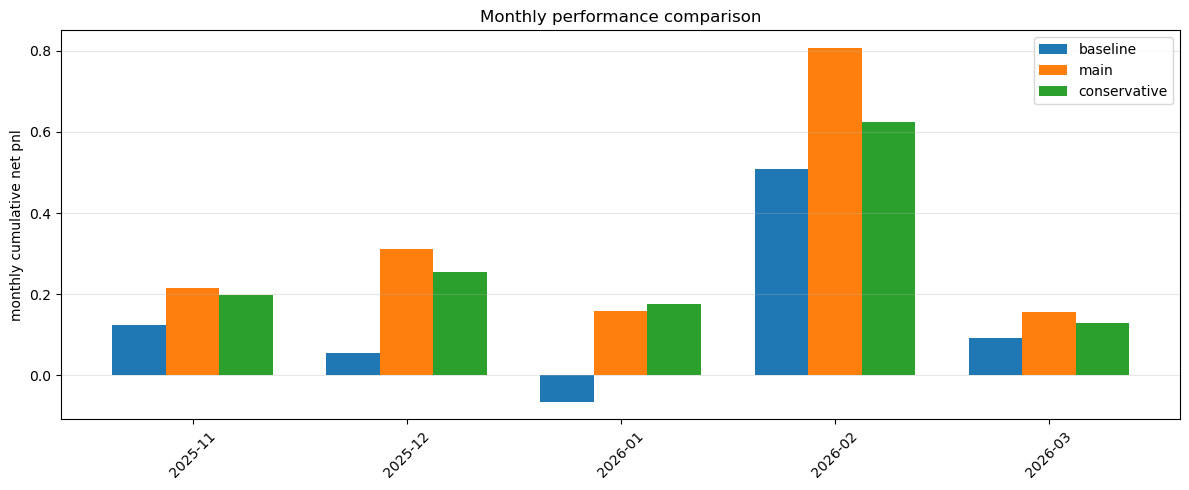

In [46]:
def plot_monthly_cum_pnl_compare(month_compare: pd.DataFrame):
    x = np.arange(len(month_compare))
    w = 0.25

    plt.figure(figsize=(12, 5))
    plt.bar(x - w, month_compare["baseline_cum_pnl"], width=w, label="baseline")
    plt.bar(x, month_compare["main_cum_pnl"], width=w, label="main")
    plt.bar(x + w, month_compare["cons_cum_pnl"], width=w, label="conservative")
    plt.xticks(x, month_compare["month"], rotation=45)
    plt.ylabel("monthly cumulative net pnl")
    plt.title("Monthly performance comparison")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_monthly_cum_pnl_compare(month_compare)

## More realistic trading constraints

We now add more realistic constraints in stages:

1. max holding period
2. fixed position sizing from capital
3. next-bar execution
4. fee + slippage assumptions

In [48]:
def run_basis_zscore_strategy_with_max_hold(
    df: pd.DataFrame,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    cost_bps: float = 2.0,
    vol_filter_col: Optional[str] = None,
    vol_filter_quantile: float = 0.80,
    vol_filter_lookback_min: int = 30 * 24 * 60,
    high_vol_only: bool = False,
    max_holding_min: Optional[int] = 120,
) -> pd.DataFrame:
    out = (
        df.copy()
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"], keep="last")
          .reset_index(drop=True)
    )

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if vol_filter_col is not None:
        VW = int(round(vol_filter_lookback_min / freq_min))
        out["vol_filter_threshold"] = (
            out[vol_filter_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(vol_filter_quantile)
            .shift(1)
        )
    else:
        out["vol_filter_threshold"] = np.nan

    pos = np.zeros(len(out), dtype=float)
    hold_bars = 0
    max_holding_bars = None if max_holding_min is None else int(round(max_holding_min / freq_min))

    for i in range(1, len(out)):
        prev_pos = pos[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            pos[i] = prev_pos
            if prev_pos != 0:
                hold_bars += 1
            continue

        if prev_pos != 0:
            hold_bars += 1

        force_exit = False
        if max_holding_bars is not None and prev_pos != 0 and hold_bars >= max_holding_bars:
            force_exit = True

        if force_exit:
            prev_pos = 0
            hold_bars = 0
        else:
            if prev_pos == 1 and abs(z) < exit_z:
                prev_pos = 0
                hold_bars = 0
            elif prev_pos == -1 and abs(z) < exit_z:
                prev_pos = 0
                hold_bars = 0

        if prev_pos == 0:
            allow_entry = True
            if vol_filter_col is not None:
                thr = out.at[i, "vol_filter_threshold"]
                sig = out.at[i, vol_filter_col]
                if pd.isna(thr) or pd.isna(sig):
                    allow_entry = False
                else:
                    allow_entry = bool(sig >= thr) if high_vol_only else bool(sig <= thr)

            if allow_entry:
                if z > entry_z:
                    prev_pos = -1
                    hold_bars = 0
                elif z < -entry_z:
                    prev_pos = 1
                    hold_bars = 0

        pos[i] = prev_pos

    out["position"] = pos
    out["gross_pnl"] = out["position"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0)
    turn = np.abs(out["position"].diff().fillna(out["position"]))
    out["trade_cost"] = turn * (cost_bps / 1e4)
    out["net_pnl"] = out["gross_pnl"] - out["trade_cost"]
    return out


def run_max_hold_sensitivity_main(df: pd.DataFrame):
    rows = []
    bt_store = {}

    holds = [30, 60, 120, 240, None]

    for h in holds:
        label = "none" if h is None else str(h)

        bt = run_basis_zscore_strategy_with_max_hold(
            df=df,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=1.5,
            exit_z=1.0,
            cost_bps=2.0,
            vol_filter_col="basis_rv_30m",
            vol_filter_quantile=0.80,
            vol_filter_lookback_min=30 * 24 * 60,
            high_vol_only=True,
            max_holding_min=h,
        )
        bt_store[f"main_hold_{label}"] = bt

        row = summarize_backtest(bt, freq_min=1).to_dict()
        row["max_holding_min"] = h
        rows.append(row)

    return pd.DataFrame(rows), bt_store


summary_hold, bt_hold_store = run_max_hold_sensitivity_main(df_all)
summary_hold

,ann_return,ann_vol,sharpe,cum_net_pnl,cum_gross_pnl,max_drawdown,n_bars,n_trade_opens,max_holding_min
0,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,30.0
1,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,60.0
2,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,120.0
3,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,240.0
4,4.694109,0.225675,20.800271,1.648207,2.555007,-0.026417,184550.0,2267.0,NaN


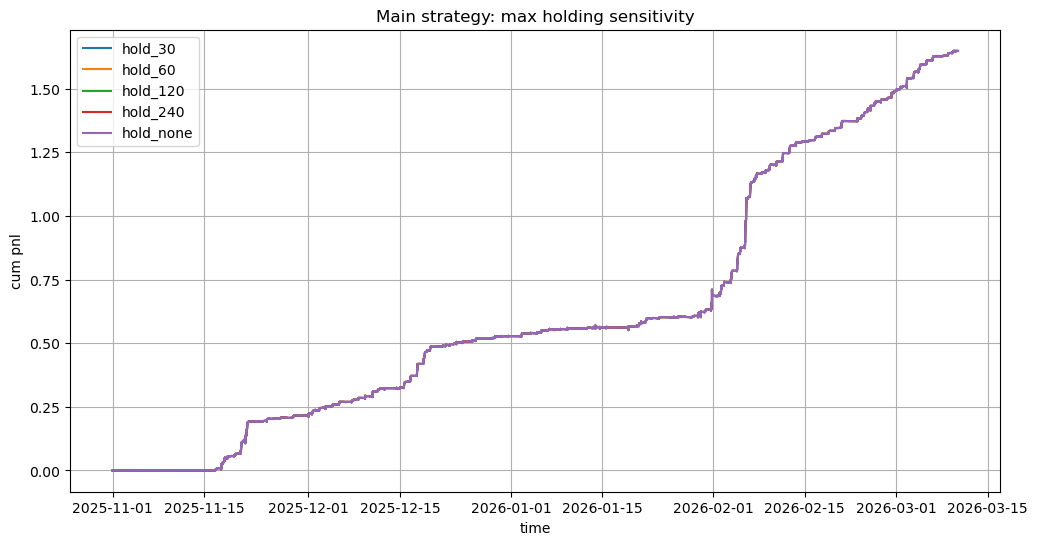

In [49]:
plot_cum_pnl(
    {
        "hold_30": bt_hold_store["main_hold_30"],
        "hold_60": bt_hold_store["main_hold_60"],
        "hold_120": bt_hold_store["main_hold_120"],
        "hold_240": bt_hold_store["main_hold_240"],
        "hold_none": bt_hold_store["main_hold_none"],
    },
    title="Main strategy: max holding sensitivity"
)

In [54]:
def z_to_size_multiplier(abs_z: float, entry_z: float) -> float:
    if np.isnan(abs_z) or abs_z < entry_z:
        return 0.0
    elif abs_z < entry_z + 0.5:
        return 0.50
    elif abs_z < entry_z + 1.0:
        return 0.75
    else:
        return 1.00


def run_level1_backtest(
    df: pd.DataFrame,
    initial_capital: float = 100000.0,
    max_position_fraction: float = 0.10,
    basis_lookback_min: int = 240,
    freq_min: int = 1,
    entry_z: float = 1.5,
    exit_z: float = 1.0,
    max_holding_min: int | None = 120,
    regime_signal_col: str | None = "basis_rv_30m",
    regime_quantile: float = 0.80,
    regime_lookback_min: int = 30 * 24 * 60,
    fee_bps: float = 2.5,
    slippage_bps: float = 2.5,
):
    out = df.copy().sort_values("timestamp").reset_index(drop=True)

    W = int(round(basis_lookback_min / freq_min))
    out["basis_mean"] = out["basis"].rolling(W, min_periods=W).mean()
    out["basis_std"] = out["basis"].rolling(W, min_periods=W).std()
    out["basis_z"] = (out["basis"] - out["basis_mean"]) / (out["basis_std"] + 1e-12)

    if regime_signal_col is not None:
        VW = int(round(regime_lookback_min / freq_min))
        out["regime_threshold"] = (
            out[regime_signal_col]
            .rolling(VW, min_periods=max(100, int(0.5 * VW)))
            .quantile(regime_quantile)
            .shift(1)
        )
        out["allow_entry"] = (out[regime_signal_col] >= out["regime_threshold"]).astype(float)
        out.loc[out["regime_threshold"].isna(), "allow_entry"] = 0.0
    else:
        out["allow_entry"] = 1.0

    max_holding_bars = None if max_holding_min is None else int(round(max_holding_min / freq_min))

    position_dir = np.zeros(len(out), dtype=float)
    hold_bars = 0

    for i in range(1, len(out)):
        prev = position_dir[i - 1]
        z = out.at[i, "basis_z"]

        if pd.isna(z):
            position_dir[i] = prev
            if prev != 0:
                hold_bars += 1
            continue

        if prev != 0:
            hold_bars += 1

        if max_holding_bars is not None and prev != 0 and hold_bars >= max_holding_bars:
            prev = 0
            hold_bars = 0
        else:
            if prev == 1 and abs(z) < exit_z:
                prev = 0
                hold_bars = 0
            elif prev == -1 and abs(z) < exit_z:
                prev = 0
                hold_bars = 0

        if prev == 0 and bool(out.at[i, "allow_entry"]):
            if z > entry_z:
                prev = -1
                hold_bars = 0
            elif z < -entry_z:
                prev = 1
                hold_bars = 0

        position_dir[i] = prev

    out["position_dir"] = position_dir
    out["z_size_multiplier"] = out["basis_z"].abs().apply(lambda z: z_to_size_multiplier(z, entry_z=entry_z))

    out["notional"] = initial_capital * max_position_fraction * out["z_size_multiplier"]
    out["gross_pnl_dollars"] = out["position_dir"].shift(1).fillna(0.0) * out["basis_ret"].fillna(0.0) * out["notional"].shift(1).fillna(0.0)

    turn = np.abs(out["position_dir"].diff().fillna(out["position_dir"]))
    total_cost_bps = fee_bps + slippage_bps
    out["trade_cost_dollars"] = turn * (total_cost_bps / 1e4) * out["notional"]

    out["net_pnl_dollars"] = out["gross_pnl_dollars"] - out["trade_cost_dollars"]
    out["cum_pnl_dollars"] = out["net_pnl_dollars"].cumsum()

    out["nav"] = initial_capital + out["cum_pnl_dollars"]
    out["nav_ret"] = out["nav"].pct_change().fillna(0.0)
    out["cum_return"] = out["nav"] / initial_capital - 1.0

    return out


def summarize_level1(bt: pd.DataFrame, freq_min: int = 1) -> pd.Series:
    r = bt["nav_ret"].fillna(0.0)
    periods_per_year = 365 * 24 * (60 // freq_min)

    ann_return = r.mean() * periods_per_year
    ann_vol = r.std() * np.sqrt(periods_per_year) if r.std() > 0 else np.nan
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan

    cum_curve = bt["cum_pnl_dollars"].ffill().fillna(0.0)
    peak = cum_curve.cummax()
    dd = cum_curve - peak

    return pd.Series({
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "final_nav": bt["nav"].iloc[-1],
        "cum_return": bt["cum_return"].iloc[-1],
        "max_drawdown": dd.min(),
    })


initial_capital = 1000.0
bt_level1_main = run_level1_backtest(
    df_all,
    initial_capital=initial_capital,
    max_position_fraction=0.05,
    basis_lookback_min=240,
    freq_min=1,
    entry_z=1.5,
    exit_z=1.0,
    max_holding_min=120,
    regime_signal_col="basis_rv_30m",
    regime_quantile=0.80,
    regime_lookback_min=30 * 24 * 60,
    fee_bps=2.5,
    slippage_bps=2.5,
)

summarize_level1(bt_level1_main, freq_min=1)

ann_return         0.184911
ann_vol            0.010461
sharpe            17.676787
final_nav       1067.060087
cum_return         0.067060
max_drawdown      -1.363512
dtype: float64

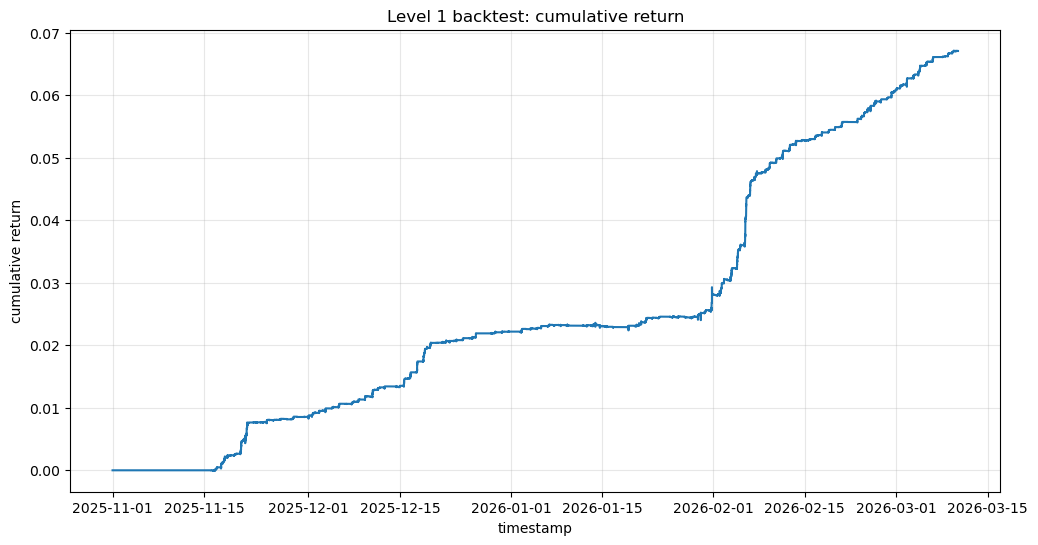

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(bt_level1_main["timestamp"], bt_level1_main["cum_return"])
plt.title("Level 1 backtest: cumulative return")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.grid(True, alpha=0.3)
plt.show()

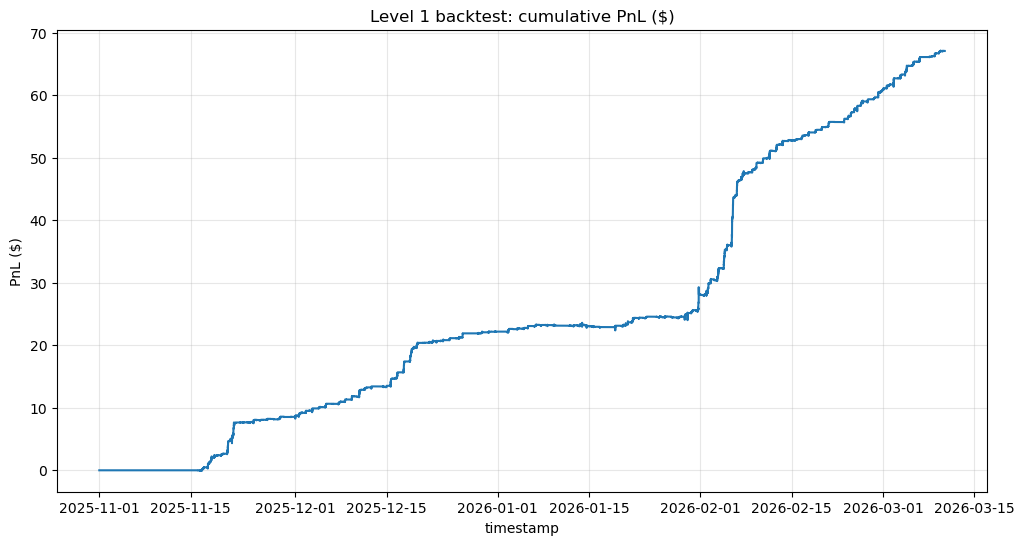

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(bt_level1_main["timestamp"], bt_level1_main["nav"] - initial_capital)
plt.title("Level 1 backtest: cumulative PnL ($)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.grid(True, alpha=0.3)
plt.show()

## Level-1 fee / slippage sensitivity

Now we hold the overall strategy structure fixed and vary explicit friction assumptions.

In [55]:
def run_level1_cost_sensitivity(
    df: pd.DataFrame,
    initial_capital: float = 1000.0,
    max_position_fraction: float = 0.05,
    cost_pairs=((0.5, 0.5), (1.0, 1.0), (2.5, 2.5), (5.0, 5.0), (10.0, 0.0)),
):
    rows = []
    bt_store = {}

    for fee_bps, slippage_bps in cost_pairs:
        label = f"fee{fee_bps}_slip{slippage_bps}"

        bt = run_level1_backtest(
            df,
            initial_capital=initial_capital,
            max_position_fraction=max_position_fraction,
            basis_lookback_min=240,
            freq_min=1,
            entry_z=1.5,
            exit_z=1.0,
            max_holding_min=120,
            regime_signal_col="basis_rv_30m",
            regime_quantile=0.80,
            regime_lookback_min=30 * 24 * 60,
            fee_bps=fee_bps,
            slippage_bps=slippage_bps,
        )
        bt_store[label] = bt

        row = summarize_level1(bt, freq_min=1).to_dict()
        row["fee_bps"] = fee_bps
        row["slippage_bps"] = slippage_bps
        row["total_cost_bps"] = fee_bps + slippage_bps
        rows.append(row)

    return pd.DataFrame(rows), bt_store


summary_l1_cost, bt_l1_cost = run_level1_cost_sensitivity(
    df_all,
    initial_capital=1000.0,
    max_position_fraction=0.05,
    cost_pairs=((0.5, 0.5), (1.0, 1.0), (2.5, 2.5), (5.0, 5.0), (10.0, 0.0)),
)

summary_l1_cost

,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,fee_bps,slippage_bps,total_cost_bps
0,0.279137,0.010147,27.508632,1102.955087,0.102955,-1.155519,0.5,0.5,1.0
1,0.255871,0.010210,25.061083,1093.981337,0.093981,-1.160470,1.0,1.0,2.0
2,0.184911,0.010461,17.676787,1067.060087,0.067060,-1.363512,2.5,2.5,5.0
3,0.062572,0.011088,5.642964,1022.191337,0.022191,-8.956032,5.0,5.0,10.0
4,0.062572,0.011088,5.642964,1022.191337,0.022191,-8.956032,10.0,0.0,10.0


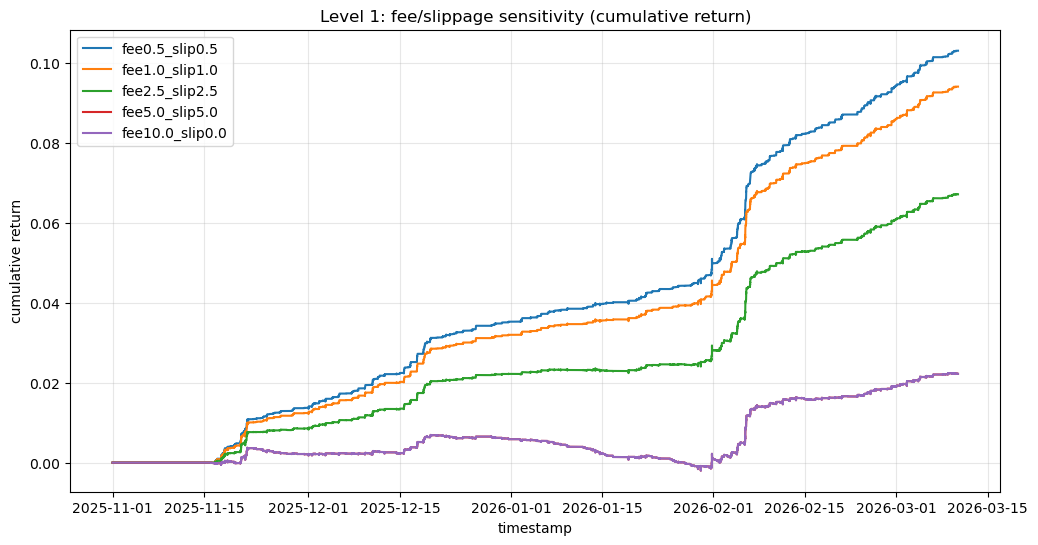

In [56]:
plt.figure(figsize=(12, 6))
for name, bt in bt_l1_cost.items():
    plt.plot(bt["timestamp"], bt["cum_return"], label=name)
plt.title("Level 1: fee/slippage sensitivity (cumulative return)")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

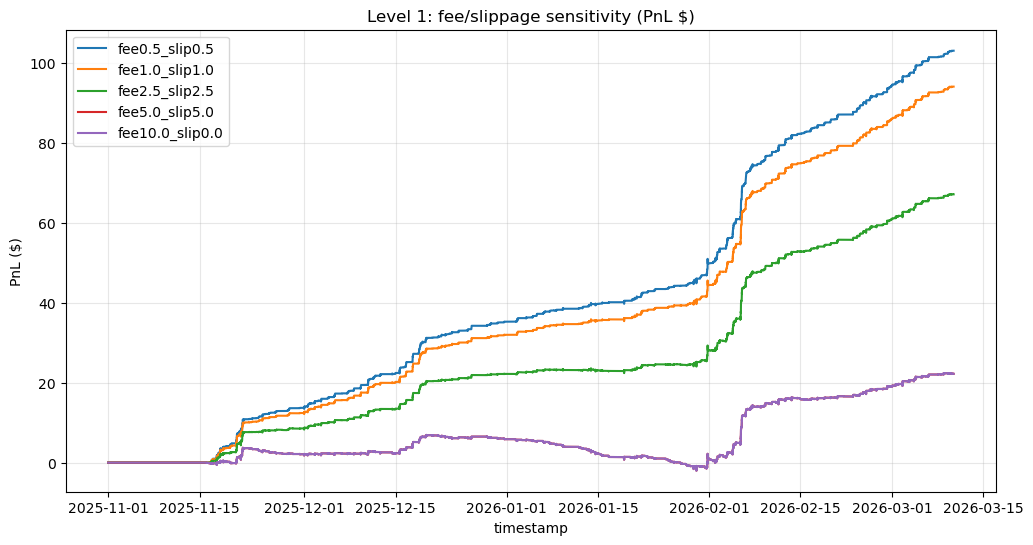

In [57]:
plt.figure(figsize=(12, 6))
for name, bt in bt_l1_cost.items():
    plt.plot(bt["timestamp"], bt["cum_pnl_dollars"], label=name)
plt.title("Level 1: fee/slippage sensitivity (PnL $)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Realistic-cost grid search

Because costs change the preferred parameter region, we now run a broader realistic-cost sweep.

In [58]:
def run_level1_grid_search(
    df: pd.DataFrame,
    initial_capital: float = 1000.0,
    max_position_fraction: float = 0.05,
    fee_bps: float = 2.5,
    slippage_bps: float = 2.5,
    regime_signals=("basis_rv_30m", "basis_vol_30m"),
    quantiles=(0.80, 0.85, 0.90, 0.95),
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.5, 1.0),
    lookback_list=(120, 240, 360),
    max_holding_min: int = 120,
):
    rows = []
    bt_store = {}

    for regime_signal in regime_signals:
        for q in quantiles:
            for entry_z in entry_list:
                for exit_z in exit_list:
                    for lookback in lookback_list:
                        name = f"{regime_signal}_q{int(q*100)}_e{entry_z}_x{exit_z}_lb{lookback}"

                        bt = run_level1_backtest(
                            df,
                            initial_capital=initial_capital,
                            max_position_fraction=max_position_fraction,
                            basis_lookback_min=lookback,
                            freq_min=1,
                            entry_z=entry_z,
                            exit_z=exit_z,
                            max_holding_min=max_holding_min,
                            regime_signal_col=regime_signal,
                            regime_quantile=q,
                            regime_lookback_min=30 * 24 * 60,
                            fee_bps=fee_bps,
                            slippage_bps=slippage_bps,
                        )
                        bt_store[name] = bt

                        row = summarize_level1(bt, freq_min=1).to_dict()
                        row.update({
                            "name": name,
                            "regime_signal": regime_signal,
                            "quantile": q,
                            "entry_z": entry_z,
                            "exit_z": exit_z,
                            "basis_lookback_min": lookback,
                        })
                        rows.append(row)

    out = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
    return out, bt_store


summary_realistic, bt_realistic_store = run_level1_grid_search(
    df_all,
    initial_capital=1000.0,
    max_position_fraction=0.05,
    fee_bps=5.0,
    slippage_bps=2.5,
    regime_signals=("basis_rv_30m", "basis_vol_30m"),
    quantiles=(0.80, 0.85, 0.90, 0.95),
    entry_list=(1.5, 2.0, 2.5),
    exit_list=(0.5, 1.0),
    lookback_list=(120, 240, 360),
    max_holding_min=120,
)

summary_realistic.head(10)

,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,name,regime_signal,quantile,entry_z,exit_z,basis_lookback_min
0,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_vol_30m_q90_e1.5_x1.0_lb120,basis_vol_30m,0.90,1.5,1.0,120
1,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_rv_30m_q90_e1.5_x1.0_lb120,basis_rv_30m,0.90,1.5,1.0,120
2,0.137889,0.009410,14.653424,1049.590780,0.049591,-1.093820,basis_vol_30m_q90_e2.0_x1.0_lb120,basis_vol_30m,0.90,2.0,1.0,120
3,0.137889,0.009410,14.653424,1049.590780,0.049591,-1.093820,basis_rv_30m_q90_e2.0_x1.0_lb120,basis_rv_30m,0.90,2.0,1.0,120
4,0.130968,0.008960,14.617633,1047.044627,0.047045,-1.223394,basis_rv_30m_q95_e1.5_x1.0_lb120,basis_rv_30m,0.95,1.5,1.0,120
5,0.130968,0.008960,14.617633,1047.044627,0.047045,-1.223394,basis_vol_30m_q95_e1.5_x1.0_lb120,basis_vol_30m,0.95,1.5,1.0,120
6,0.141547,0.009810,14.428607,1050.938364,0.050938,-1.226951,basis_vol_30m_q90_e2.0_x1.0_lb240,basis_vol_30m,0.90,2.0,1.0,240
7,0.141547,0.009810,14.428607,1050.938364,0.050938,-1.226951,basis_rv_30m_q90_e2.0_x1.0_lb240,basis_rv_30m,0.90,2.0,1.0,240
8,0.145011,0.010104,14.352221,1052.216310,0.052216,-1.233913,basis_rv_30m_q90_e2.0_x1.0_lb360,basis_rv_30m,0.90,2.0,1.0,360
9,0.145011,0.010104,14.352221,1052.216310,0.052216,-1.233913,basis_vol_30m_q90_e2.0_x1.0_lb360,basis_vol_30m,0.90,2.0,1.0,360


In [59]:
best_by_signal = (
    summary_realistic
    .sort_values("sharpe", ascending=False)
    .groupby("regime_signal", as_index=False)
    .first()
    .sort_values("sharpe", ascending=False)
)

best_by_signal

,regime_signal,ann_return,ann_vol,sharpe,final_nav,cum_return,max_drawdown,name,quantile,entry_z,exit_z,basis_lookback_min
0,basis_rv_30m,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_rv_30m_q90_e1.5_x1.0_lb120,0.9,1.5,1.0,120
1,basis_vol_30m,0.145569,0.009903,14.700042,1052.423165,0.052423,-1.281763,basis_vol_30m_q90_e1.5_x1.0_lb120,0.9,1.5,1.0,120


In [60]:
summary_realistic.groupby(["regime_signal", "quantile"])["sharpe"].mean().unstack()

quantile,0.80,0.85,0.90,0.95
regime_signal,,,,
basis_rv_30m,11.799664,12.518531,13.286576,12.839877
basis_vol_30m,11.799664,12.518531,13.286576,12.839877


In [61]:
summary_realistic.groupby(["entry_z", "exit_z"])["sharpe"].mean().unstack()

exit_z,0.5,1.0
entry_z,,
1.5,11.526522,13.152059
2.0,11.764295,13.844751
2.5,11.734583,13.644762


In [62]:
summary_realistic.groupby("basis_lookback_min")["sharpe"].mean()

basis_lookback_min
120    12.929970
240    12.467128
360    12.436387
Name: sharpe, dtype: float64

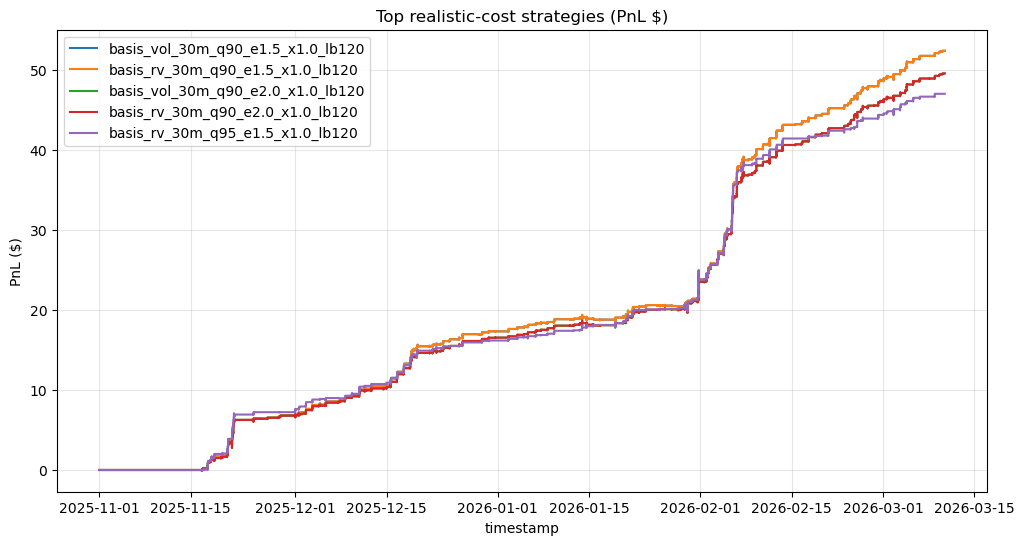

In [63]:
top_names = summary_realistic.head(5)["name"].tolist()

plt.figure(figsize=(12, 6))
for n in top_names:
    bt = bt_realistic_store[n]
    cum_pnl_dollars = bt["nav"] - bt["nav"].iloc[0]
    plt.plot(bt["timestamp"], cum_pnl_dollars, label=n)
plt.title("Top realistic-cost strategies (PnL $)")
plt.xlabel("timestamp")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

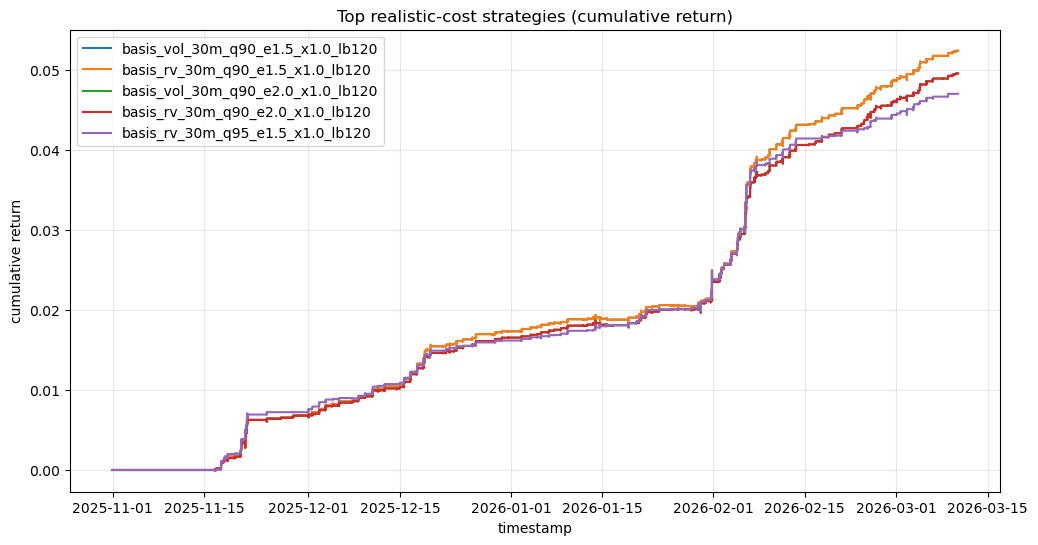

In [64]:
plt.figure(figsize=(12, 6))
for n in top_names:
    bt = bt_realistic_store[n]
    plt.plot(bt["timestamp"], bt["cum_return"], label=n)
plt.title("Top realistic-cost strategies (cumulative return)")
plt.xlabel("timestamp")
plt.ylabel("cumulative return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final notebook takeaways

### Main conclusions

1. Simple suppression of high-activity regimes is not the main source of improvement.
2. Basis-native regime signals are stronger than a naive “avoid volatility” framing.
3. The most useful signals are based on:
   - `basis_rv_30m`
   - `basis_vol_30m`
4. High-vol-only activation is generally more effective than soft suppression.
5. Under more realistic trading frictions, the preferred region shifts toward:
   - higher quantiles such as q95
   - entry_z around 2.0–2.5
   - lookback around 120, with 240 as a secondary choice

### Practical summary from the original notebook comments

- regime signal: `basis_rv_30m` or `basis_vol_30m`
- quantile: q95
- exit_z: 1.0
- basis_lookback_min: 120 best, 240 second
- entry_z: 2.0 or 2.5 both reasonable

This is the strongest practical version under the notebook's more realistic friction assumptions.